
C**ontexto del Problema:**
Tenemos un dataset de diabetes que recopila los datos clínicos de 768 pacientes. El objetivo principal es realizar un Análisis Exploratorio de Datos (EDA) para identificar anomalías y, posteriormente, diseñar, entrenar y evaluar una Red Neuronal Multicapa (MLP) capaz de clasificar si un paciente presenta diabetes (Outcome = 1) o no (Outcome = 0).

El conjunto de datos cuenta con las siguientes variables:

Pregnancies: Número de veces que la paciente ha estado embarazada.

Glucose: Concentración de glucosa en plasma a las 2 horas en una prueba de tolerancia oral.

BloodPressure: Presión arterial diastólica medida en mm Hg.

SkinThickness: Grosor del pliegue cutáneo del tríceps en mm.

Insulin: Insulina sérica de 2 horas.

BMI: Índice de masa corporal (peso en kg dividido entre la altura en metros al cuadrado).

DiabetesPedigreeFunction: Función que evalúa la probabilidad de diabetes basándose en los antecedentes familiares.

Age: Edad de la paciente en años.

Outcome (Variable Objetivo): Diagnóstico final, donde 0 representa que el paciente está sano y 1 representa que tiene diabetes.


E**stadísticas Numéricas Cruciales**
Antes de los gráficos, necesitamos los números duros. Este bloque te mostrará un resumen estadístico detallado y te calculará exactamente cuántos "falsos ceros" (datos faltantes) e inválidos tiene cada columna numéricamente.

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os

# 1. Cargar el dataset
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("==========================================================")
print("             1. ESTADÍSTICA DESCRIPTIVA GENERAL           ")
print("==========================================================")
# .describe().T nos da: conteo, media, desviación estándar, mínimo, cuartiles y máximo
print(df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

print("\n==========================================================")
print("          2. RECUENTO EXACTO DE 'FALSOS CEROS'            ")
print("==========================================================")
col_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in col_con_ceros:
    cant_ceros = (df[col] == 0).sum()
    pct_ceros = (cant_ceros / len(df)) * 100
    print(f"-> Columna '{col}': {cant_ceros} registros inválidos en '0' ({pct_ceros:.2f}%)")

Using Colab cache for faster access to the 'diabetes-dataset' dataset.
             1. ESTADÍSTICA DESCRIPTIVA GENERAL           
                          count        mean         std     min       25%  \
Pregnancies               768.0    3.845052    3.369578   0.000   1.00000   
Glucose                   768.0  120.894531   31.972618   0.000  99.00000   
BloodPressure             768.0   69.105469   19.355807   0.000  62.00000   
SkinThickness             768.0   20.536458   15.952218   0.000   0.00000   
Insulin                   768.0   79.799479  115.244002   0.000   0.00000   
BMI                       768.0   31.992578    7.884160   0.000  27.30000   
DiabetesPedigreeFunction  768.0    0.471876    0.331329   0.078   0.24375   
Age                       768.0   33.240885   11.760232  21.000  24.00000   
Outcome                   768.0    0.348958    0.476951   0.000   0.00000   

                               50%        75%     max  
Pregnancies                 3.0000    6.000

**Diagramas de Caja y Bigotes**(Detección de Outliers)
Los diagramas de caja (Boxplots) dividen los datos en cuartiles. Los puntos que verás dibujados de forma individual fuera de los "bigotes" (líneas extremas) son los outliers numéricos que deberás considerar.

/tmp/ipykernel_4119/4029521363.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/4029521363.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/4029521363.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/4029521363.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

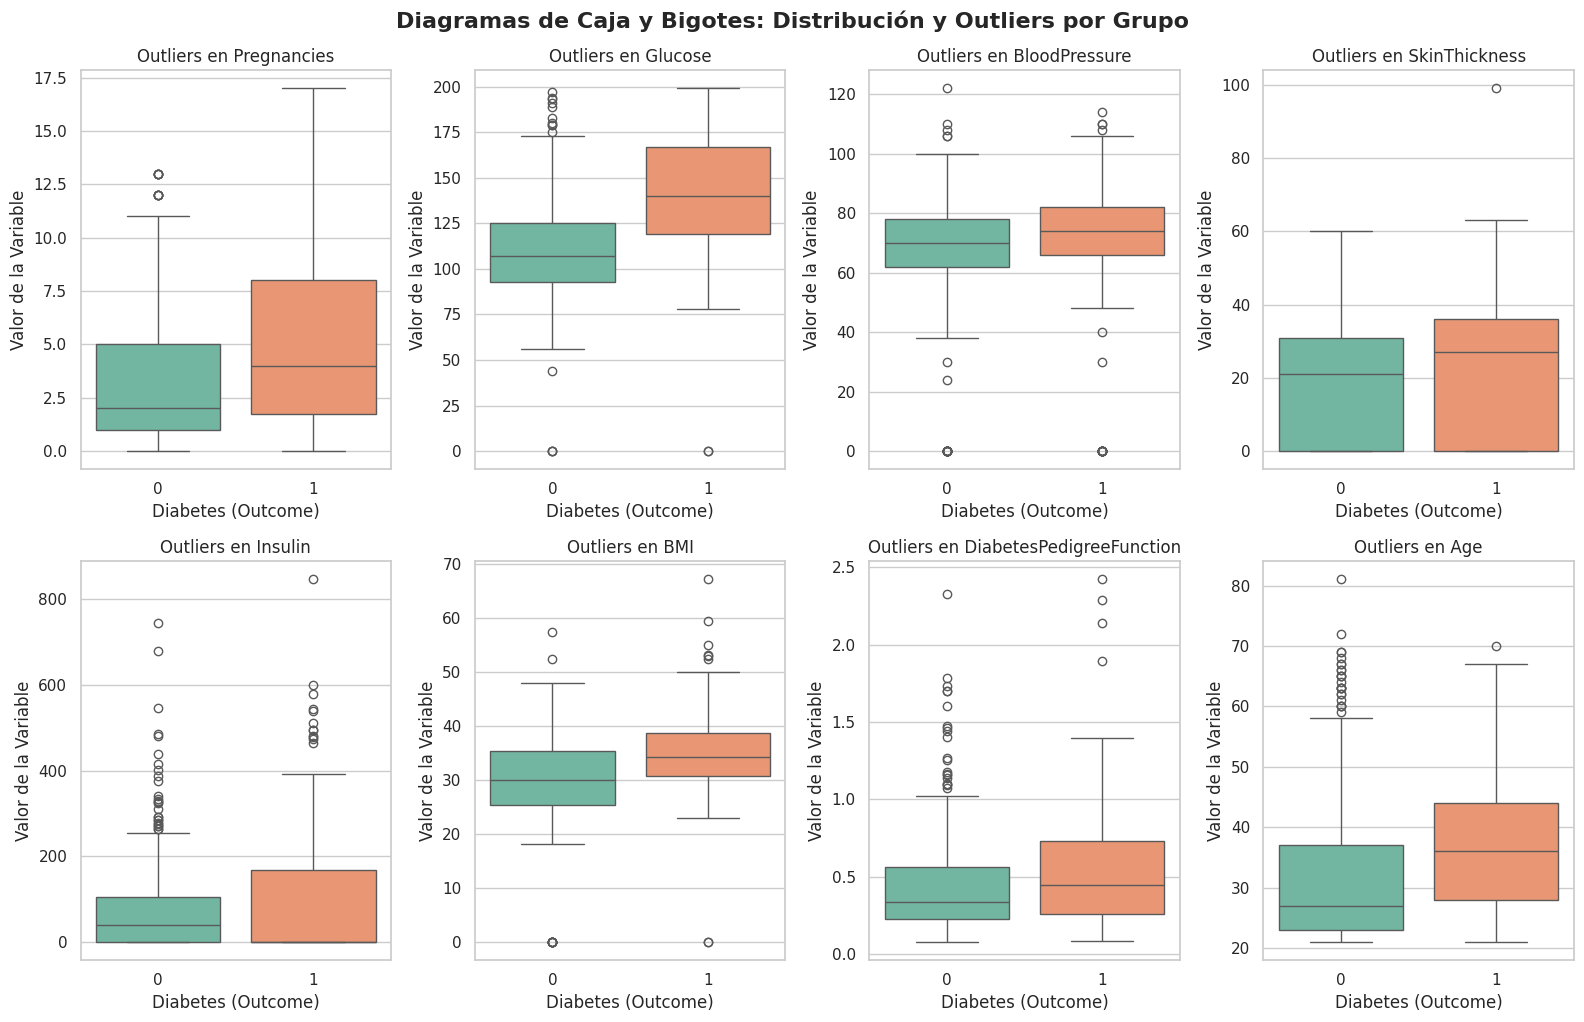

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual
sns.set_theme(style="whitegrid")
features = df.drop(columns=['Outcome']).columns

# Crear rejilla de gráficos para los Boxplots
plt.figure(figsize=(16, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 4, i)
    # Graficamos el boxplot diferenciando entre Sanos (0) y Diabéticos (1) para mayor profundidad
    sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
    plt.title(f'Outliers en {col}')
    plt.xlabel('Diabetes (Outcome)')
    plt.ylabel('Valor de la Variable')

plt.tight_layout()
plt.suptitle('Diagramas de Caja y Bigotes: Distribución y Outliers por Grupo', y=1.02, fontsize=16, fontweight='bold')
plt.show()

### Resumen del Diagnóstico de los Gráficos:
1. **Falsos Ceros (Datos Faltantes Ocultos):** Variables como `Glucose`, `BloodPressure` y `BMI` muestran registros inválidos en el valor exacto de `0`. En `Insulin` y `SkinThickness` el problema es crítico, ya que casi la mitad de los datos están aplastados en cero.
2. **Separación de Clases:** `Glucose` y `BMI` son los mejores predictores, ya que las cajas de pacientes con diabetes (`1`) están notablemente más elevadas que las de pacientes sanos (`0`).
3. **Presencia de Outliers:** `Insulin` y `DiabetesPedigreeFunction` presentan valores atípicos extremos muy altos que pueden distorsionar el aprendizaje de la red neuronal.

### Estrategia de Corrección en Código:
* Convertiremos los ceros imposibles a valores nulos (`NaN`).
* Reemplazaremos esos `NaN` usando la **mediana calculada por grupo** (`Outcome`), evitando así que los datos atípicos arrastren la media y asegurando una distribución limpia para la Red Neuronal.

CURAR LOS DATOS

Descargando el dataset...
Using Colab cache for faster access to the 'diabetes-dataset' dataset.
¡Limpieza completada! Ceros corregidos.


/tmp/ipykernel_4119/2101024104.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/2101024104.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/2101024104.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
/tmp/ipykernel_4119/2101024104.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` va

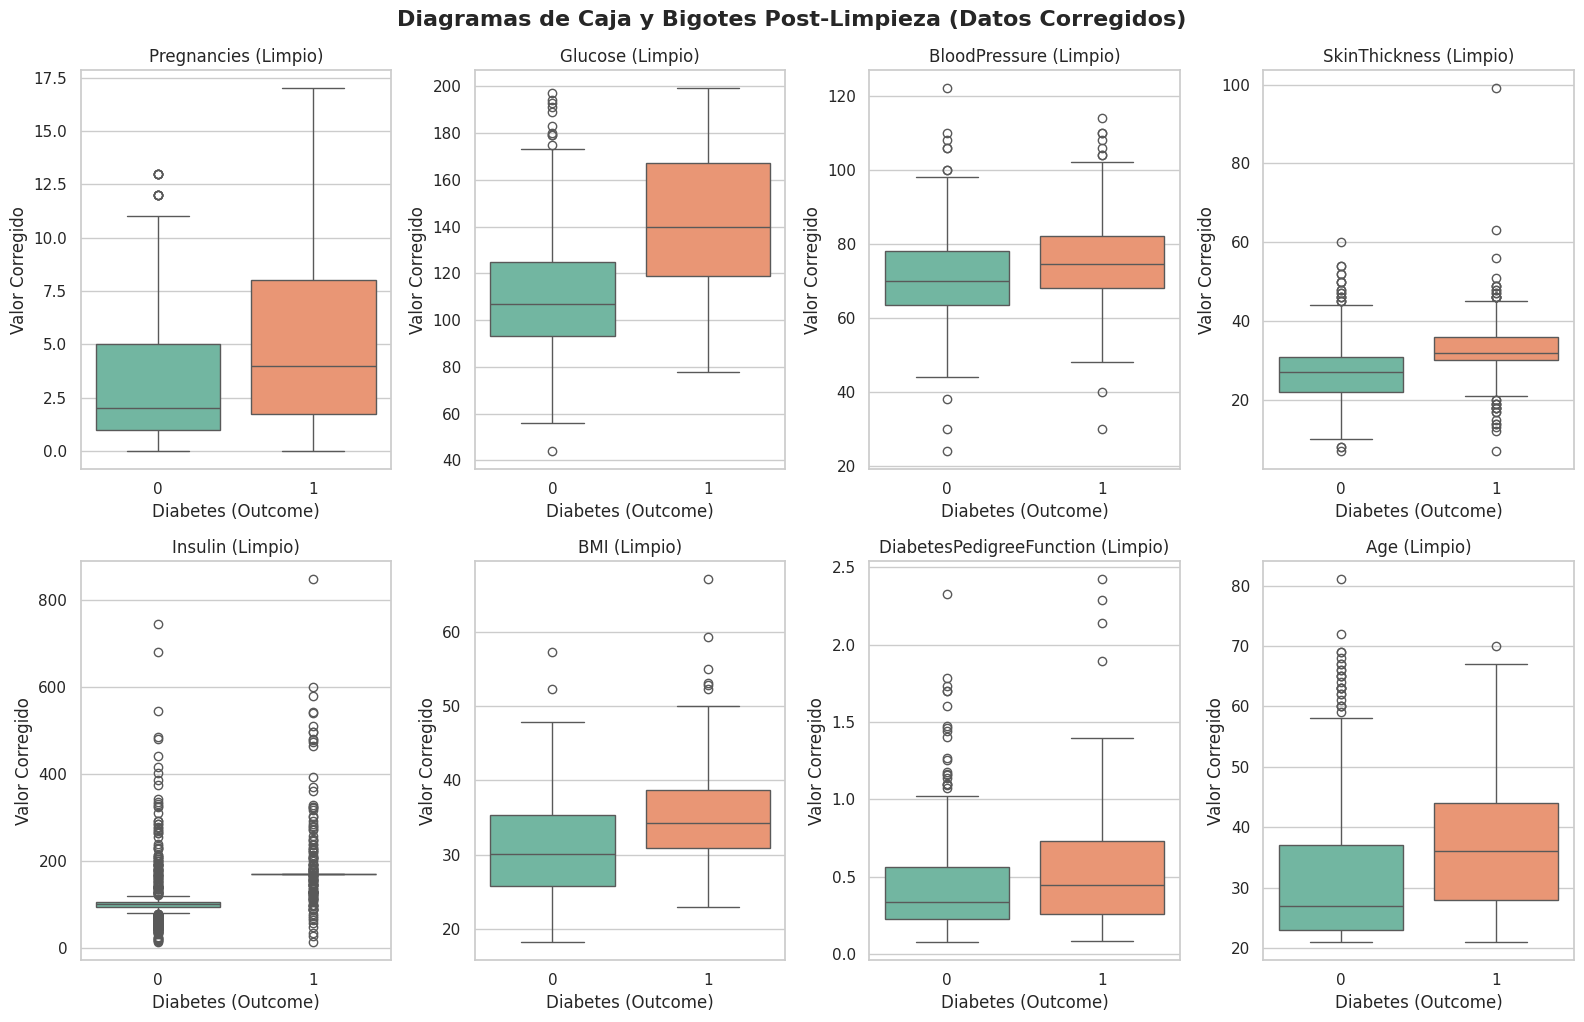

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DESCARGA Y CARGA DEL DATASET
# ==========================================
print("Descargando el dataset...")
path = kagglehub.dataset_download("akshaydattatraykhare/diabetes-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# ==========================================
# 2. ESTRATEGIA DE CORRECCIÓN (LIMPIEZA)
# ==========================================
# Identificamos las columnas con ceros clínicamente imposibles
columnas_invalidas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Convertimos esos ceros a NaN para aislarlos
df[columnas_invalidas] = df[columnas_invalidas].replace(0, np.nan)

# Reemplazamos los NaN por la mediana de su respectivo grupo (Outcome 0 u Outcome 1)
for col in columnas_invalidas:
    mediana_grupo = df.groupby('Outcome')[col].transform('median')
    df[col] = df[col].fillna(mediana_grupo)

print("¡Limpieza completada! Ceros corregidos.")

# ==========================================
# 3. VOLVER A CREAR LOS GRÁFICOS (BOXPLOTS LIMPIOS)
# ==========================================
sns.set_theme(style="whitegrid")
features = df.drop(columns=['Outcome']).columns

# Creamos la rejilla de subplots para comparar
plt.figure(figsize=(16, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 4, i)
    # Graficamos los nuevos datos limpios por grupo (0 y 1)
    sns.boxplot(x='Outcome', y=col, data=df, palette='Set2')
    plt.title(f'{col} (Limpio)')
    plt.xlabel('Diabetes (Outcome)')
    plt.ylabel('Valor Corregido')

plt.tight_layout()
plt.suptitle('Diagramas de Caja y Bigotes Post-Limpieza (Datos Corregidos)', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Fase 2: Preparación de Datos y Escalamiento (Capa de Protección)

Antes de alimentar la red neuronal, es fundamental transformar las escalas de nuestras variables. En el Análisis Exploratorio de Datos (EDA) observamos características con rangos numéricos sumamente masivos (como la `Insulina` superando los 600 o la `Glucosa` en 190) conviviendo con variables pequeñas (como `DiabetesPedigreeFunction` que es menor a 2).

Las redes neuronales son extremadamente sensibles a estas diferencias de magnitud. Si dejamos los datos en su estado bruto, los algoritmos matemáticos priorizarán las variables con números más grandes, ignorando las pequeñas y desestabilizando el ajuste de los pesos (gradientes).

### Solución: Escalamiento Z-Score (`StandardScaler`)
Aplicaremos una normalización estadística estándar. Este proceso matemático toma todas las variables y las comprime a una escala uniforme con **Media = 0** y **Desviación Estándar = 1** (la mayoría de los datos se concentrarán en un rango controlado entre -3 y 3).

**Beneficio clave:** Esta técnica neutraliza el impacto negativo de los valores atípicos (*outliers*) superiores observados en los diagramas de caja, garantizando que todas las características tengan el mismo peso matemático durante el aprendizaje.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar características (X) y la etiqueta objetivo (y)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%) de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. CREAR LA CAPA DE PROTECCIÓN: Escalamiento Z-score
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"¡Datos listos y escalados! Formato de entrenamiento: {X_train.shape}")

¡Datos listos y escalados! Formato de entrenamiento: (614, 8)


## Fase 3: Arquitectura de la Red Neuronal Multicapa (MLP)

Procedemos a diseñar la estructura de nuestra red neuronal utilizando la API secuencial de Keras. Para este problema de clasificación binaria, implementaremos una arquitectura con tres capas ocultas y mecanismos de regularización para asegurar un aprendizaje estable.

### Componentes de la Arquitectura:
1. **Capa de Entrada y Primera Capa Oculta (`Dense` de 32 neuronas):** Recibe las 8 variables médicas escaladas. Utiliza la función de activación **ReLU** ($f(x) = \max(0, x)$) para introducir no-linealidad, permitiendo al modelo aprender relaciones complejas entre los síntomas.
2. **Capas de Regularización (`Dropout`):** Intercalamos capas de Dropout (30% y 20%). Su función es "apagar" aleatoriamente una fracción de neuronas en cada iteración del entrenamiento. Esto actúa como un freno contra el sobreajuste (*overfitting*), obligando a la red a aprender patrones generales en lugar de memorizar casos aislados o valores extremos.
3. **Capas Ocultas Adicionales (16 y 8 neuronas):** Reducen paulatinamente la dimensionalidad, abstrayendo las características clave del paciente.
4. **Capa de Salida (1 neurona con función Sigmoide):** Crucial para problemas binarios. Transforma la salida final en un valor continuo estrictamente entre 0 y 1, lo cual se interpreta directamente como la **probabilidad matemática** de que el paciente presente diabetes.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Definición de la estructura secuencial
model = Sequential([
    # Capa de entrada implícita (8) + Primera capa oculta (32 neuronas)
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),  # Desactiva el 30% de las neuronas al azar por iteración

    # Segunda capa oculta
    Dense(16, activation='relu'),
    Dropout(0.3),  # Desactiva el 20% de las neuronas al azar por iteración

    # Tercera capa oculta
    Dense(8, activation='relu'),

    # Capa de salida binaria (Valores entre 0 y 1)
    Dense(1, activation='sigmoid')
])

# 2. Compilación del modelo (Establecer reglas matemáticas)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # Algoritmo de optimización
    loss='binary_crossentropy',                            # Función de pérdida para clasificación binaria
    metrics=['accuracy']                                   # Métrica de rendimiento a monitorear
)

# 3. Mostrar el reporte estructural de la red
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

## Fase 4: Proceso de Entrenamiento y Control de Parada Temprana (`EarlyStopping`)

Para entrenar la red, utilizaremos un mecanismo inteligente llamado `EarlyStopping`. El modelo iterará sobre los datos un máximo de 100 veces (`epochs`). Sin embargo, reservaremos un 20% de los datos de entrenamiento de forma interna exclusivamente para validación instantánea.

Si el algoritmo detecta que la pérdida de validación (`val_loss`) deja de disminuir durante 10 vueltas seguidas (`patience=10`), detendrá el proceso automáticamente para evitar que la red memorice ruido. Además, restaurará de forma automática los pesos exactos del momento en que la red alcanzó su mejor rendimiento.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Configurar el callback de parada temprana
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Iniciando el ajuste de pesos de la red neuronal...\n")

# 2. Ejecutar el entrenamiento (Ajuste de gradientes)
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,          # Procesa los datos en bloques de 32 pacientes
    validation_split=0.2,   # 20% de los datos para monitoreo interno
    callbacks=[early_stop],
    verbose=1
)

Iniciando el ajuste de pesos de la red neuronal...

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5173 - loss: 0.7205 - val_accuracy: 0.6911 - val_loss: 0.6561
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6802 - loss: 0.6583 - val_accuracy: 0.7561 - val_loss: 0.6224
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7067 - loss: 0.6268 - val_accuracy: 0.7561 - val_loss: 0.5895
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7189 - loss: 0.5885 - val_accuracy: 0.7642 - val_loss: 0.5537
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7312 - loss: 0.5564 - val_accuracy: 0.7886 - val_loss: 0.5211
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7495 - loss: 0.5195 - val_accuracy: 0.8130 - val_loss: 0.4915
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.4694 - val_accuracy: 0.7967 - val_loss: 0.4619
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

## Fase 5: Evaluación Final con Datos del Mundo Real

Una vez finalizado el entrenamiento, sometemos a la red neuronal a su evaluación definitiva. Utilizaremos el set de prueba (`X_test` e `y_test`), que representa un grupo de pacientes cuyas condiciones médicas **nunca fueron expuestas ante el modelo**. Esto nos dará la métrica real de precisión y capacidad de generalización del sistema en un entorno clínico real.

In [ ]:
# Evaluar la red con el set de test independiente
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("==========================================================")
print("             MÉTRICAS FINALES DE EVALUACIÓN               ")
print("==========================================================")
print(f"Pérdida Final del Modelo (Loss en Test): {loss:.4f}")
print(f"Precisión Final del Modelo (Accuracy en Test): {accuracy * 100:.2f}%")
print("==========================================================")

             MÉTRICAS FINALES DE EVALUACIÓN               
Pérdida Final del Modelo (Loss en Test): 0.4181
Precisión Final del Modelo (Accuracy en Test): 80.52%
